# Computing for Economists: Nonlinear Equation Solving and Derivative-Based Optimization
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import time
import warnings

## Exercise: Production Function Optimization

A firm wishes to maximize profits subject to a exogenous production function and inverse demand curve. For this exercise, please use the quasi-Newton method we covered in lecture: `scipy.optimize.minimize(method='BFGS')` or `'L-BFGS-B'` which is the memory efficient version.

The firm chooses the amount of capital $K$ and labor $L$:

$$\max_{K, L} P Q - wL - rK \hspace{0.5cm} s.t.$$
$$Q = f(K, L)$$
$$P = p(Q)$$

where $w$ and $r$ are wages and rent. We will ask you to solve the question with different functional forms for the production function $f(K, L)$ and inverse demand curve $p(Q)$. Let wage and rent be given by: $w = 20, r = 25$.

First assume a Cobb-Douglas production function with $A = 1, \alpha = 0.3, \beta = 0.7$:
$$f(K, L) = A K^{\alpha} L^{\beta}$$

and a linear inverse demand curve with $a = 50, b = 0.1$:
$$P = a - bQ$$

1.   Compute the profit maximizing quantities of $(K, L)$ using Python's built in minimizer for BFGS. Try the following two initial guesses: $(100, 100)$ and $(40, 20)$.

2.   What is the behavior of the optimizer under the two different initial values? Try another initial value of your own.

In [2]:
# Cobb-Douglas Production Function
def cobb_douglas_production(K, L, A = 1, alpha = 0.3, beta = 0.7):
    return A * K**alpha * L**beta

def inv_linear_demand(Q, a=50, b=0.1):
    P = a - b * Q
    return P

def profit(K, L, inv_demand_fcn, prod_fcn, w=20, r=25):
    Q = prod_fcn(K, L)
    P = inv_demand_fcn(Q)
    profit = P * Q - w * L - r * K
    return profit

def neg_profit(KL, inv_demand_fcn, prod_fcn, w=20, r=25):
    K, L = KL
    return -profit(K, L, inv_demand_fcn, prod_fcn, w, r)

In [3]:
initial_guesses = [[100, 100], [40, 20], [1000, 2000]]
K_max = 100
L_max = 150

# Cobb-Douglas
for guess in initial_guesses:
    optimal_KL = opt.minimize(neg_profit, guess, args=(inv_linear_demand, cobb_douglas_production), method='L-BFGS-B')
    print(f"Optimal K and L for initial guess {guess}: {optimal_KL.x}, Profit: {-optimal_KL.fun}")

Optimal K and L for initial guess [100, 100]: [25.07375386 73.13161237], Profit: 281.3724443354147
Optimal K and L for initial guess [40, 20]: [25.07368639 73.13148248], Profit: 281.3724443313388
Optimal K and L for initial guess [1000, 2000]: [  52.94522966 1034.7873529 ], Profit: nan


/var/folders/gd/m9hjf98j03v2xwv7_fz0y_3m0000gn/T/ipykernel_38601/1297146946.py:3: RuntimeWarning: invalid value encountered in scalar power
  return A * K**alpha * L**beta


3.   To better see what is going on, plot a contour map of profit against capital and labor. If you would like, feel free to plot another 3D visualization. Comment on the shape of the objective.

In [4]:
def plot_function(K_max, L_max, inv_demand_fcn, prod_fcn, plot_type):
    """
    Plots the production function as a 3D surface or a contour plot.

    Parameters:
    - K_max (int): The maximum value of Capital (K) to plot.
    - L_max (int): The maximum value of Labor (L) to plot.
    - prod_fcn (callable): The production function, which takes Capital (K) and Labor (L) as inputs
      and returns the output of the production process.
    - plot_type (str): Type of plot to generate. Options are '3D' for a 3D surface plot,
      or 'contour' for a contour plot.

    Raises:
    - ValueError: If `plot_type` is not '3D' or 'contour'.
    """
    # Generate a grid of K and L values
    K_values = np.linspace(0, K_max, 100)
    L_values = np.linspace(0, L_max, 100)
    K_grid, L_grid = np.meshgrid(K_values, L_values)
    Profit_grid = profit(K_grid, L_grid, inv_demand_fcn, prod_fcn)

    # Plotting
    if plot_type == '3D':
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(K_grid, L_grid, Profit_grid, cmap='viridis', edgecolor='none')
        ax.set_xlabel('Capital (K)')
        ax.set_ylabel('Labor (L)')
        ax.set_zlabel('Profit')
        ax.set_title('Profit Landscape')

        # Color bar to indicate the profit levels
        fig.colorbar(surf, shrink=0.5, aspect=5)

    elif plot_type == 'contour':
        plt.figure(figsize=(8, 6))
        contours = plt.contour(K_grid, L_grid, Profit_grid, 50, cmap='viridis')
        plt.clabel(contours, inline=True, fontsize=8, fmt="%1.0f")

        plt.xlabel('Capital (K)')
        plt.ylabel('Labor (L)')
        plt.title('Contour Plot of Profit Function')
        plt.colorbar(contours)

    else:
        raise ValueError("plot_type must be either 'contour' or '3D'")

    plt.show()

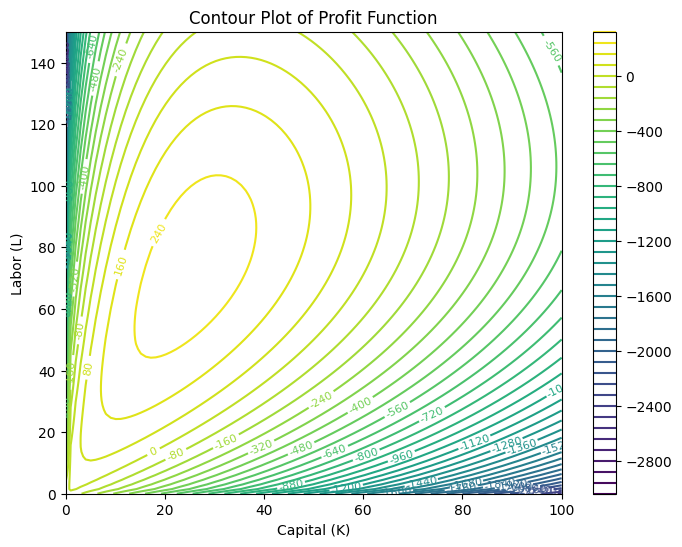

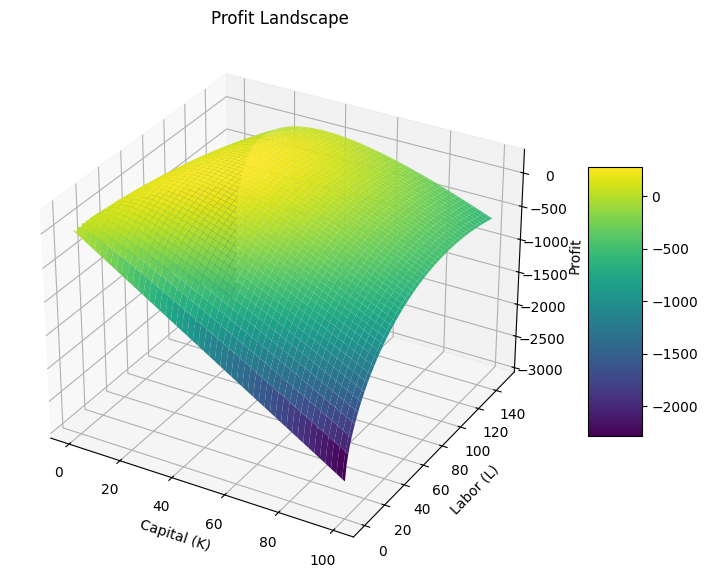

In [5]:
for plot in ['contour', '3D']:
    plot_function(K_max, L_max, inv_linear_demand, cobb_douglas_production, plot)

**Solution:** Over the range that matters economically -- where price and marginal revenue are both positive -- the objective is well behaved, and the first two guesses converge to the same unique interior optimum. It is not globally convex, though. The objective is undefined for negative $K$ or $L$ (that is the power warning above), and it stops being concave once $Q$ is large enough that marginal revenue turns negative, so a far-away start like $(1000, 2000)$ can still walk out of the domain and return `nan`.

While Cobb-Douglas is a nicely behaved function, let's consider a commonly used production function that is not smooth. Suppose now that production is Leontief with $\rho=2.5, \delta=1.5$:
$$f(K, L) = \min\{\rho K, \delta L\}$$

4.   Compute the profit maximizing quantities of $(K, L)$ using Python's built in minimizer for BFGS and with initial guesses $(100, 100)$ and $(40, 20)$. Try another one of your own initial guesses and comment on the optimizer behavior.

**Bonus:** Try the optimization again with method 'Nelder-Mead'. This is a derivative-free method that we will cover in another module. Comment on the result.

In [6]:
# Leontief Production Function
def leontief_production(K, L, rho=2.5, delta=1.5):
    return np.minimum(K * rho, L * delta)

In [7]:
# Leontief
for guess in initial_guesses:
    optimal_KL = opt.minimize(neg_profit, guess, args=(inv_linear_demand, leontief_production), method='BFGS')
    print(f"Optimal K and L for initial guess {guess}: {optimal_KL.x}, Profit: {-optimal_KL.fun}")

Optimal K and L for initial guess [100, 100]: [54.5282339  90.13691902], Profit: 1766.275260323876
Optimal K and L for initial guess [40, 20]: [25.99234    43.32056667], Profit: 1310.5715800581825
Optimal K and L for initial guess [1000, 2000]: [26.57949092 44.29915152], Profit: 1330.4227250982485


In [8]:
# Leontief (try with derivative-free method)
for guess in initial_guesses:
    optimal_KL = opt.minimize(neg_profit, guess, args=(inv_linear_demand, leontief_production), method='Nelder-Mead')
    print(f"Optimal K and L for initial guess {guess}: {optimal_KL.x}, Profit: {-optimal_KL.fun}")

Optimal K and L for initial guess [100, 100]: [53.33333972 88.88889954], Profit: 1777.7777777730942
Optimal K and L for initial guess [40, 20]: [53.33331815 88.88886359], Profit: 1777.7777777217675
Optimal K and L for initial guess [1000, 2000]: [53.33335007 88.88891678], Profit: 1777.7777777755496


**Solution:** Different starting values lead to different results with BFGS. This is not a differentiable objective function unlike Cobb-Douglas production. With a derivative free algorithm, we converge to the global optimum with different starting values.

5.   Plot a contour map (or another 3D visualization) of the objective function under Leotief production. How does it differ from Cobb-Douglas production? What makes the numerical optimization similar or different in the Leontief case?

**Bonus:**   We have not discussed constrained optimization yet. Comment on any constraints and bounds that might be important for this problem. Do you think this may affect the optimizer in some way?

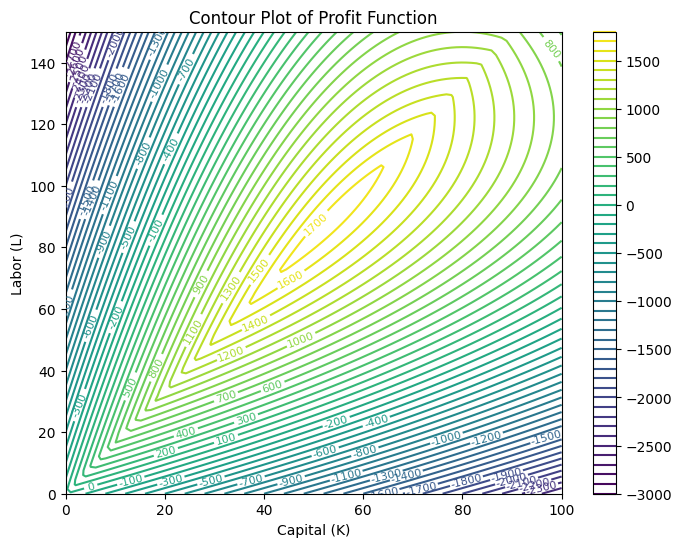

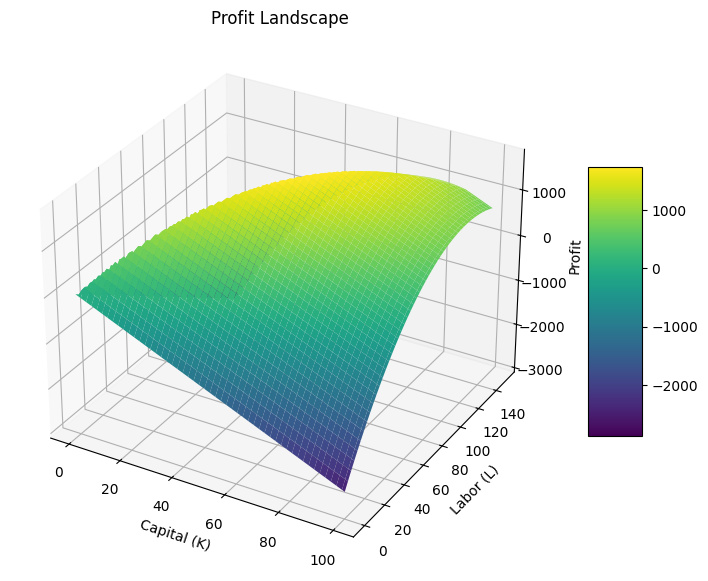

In [9]:
for plot in ['contour', '3D']:
    plot_function(K_max, L_max,inv_linear_demand, leontief_production, plot)

**Solution:** Over the same range the problem is still well behaved with a unique global optimum, however, the Leontief isoquants are L-shaped and their corners lie along the ray $\rho K = \delta L$, which puts a kink in the objective function. This can be problematic for derivative-based optimizers.

This problem does not need it, but there are also two more explicit constraints on the choice variables: $K, L \geq 0$. We may want to explicitly include those as bounds especially for problems with corner solutions.

6. Suppose the firm's production is once again Cobb-Douglas, but it is now faced with the following inverse demand:
$$P = (Q / a)^{-1/\epsilon}$$
Let $a = 100, \epsilon = 1.5$. What is the $\epsilon$ parameter and what is the economic interpretation given its value? What is the result given by the optimizer? If you are not happy with the optimizer's behavior feel free to modify your approach, but stay within what `scipy.optimize.minimize` can do. 

**Hint:** a plot of the objective function and the demand function may be helpful. Think about what you want to see in a plot, and then use AI to accurately generate a plot of the relevant relationships.

In [10]:
def inv_isoelastic(Q, a=100, epsilon=1.5):
    P = (Q / a) ** (-1 / epsilon)
    return P

# No configuration and just using bounds will not give correct answers
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    # Cobb-Douglas optimization without bounds
    for guess in initial_guesses:
        optimal_KL = opt.minimize(neg_profit, guess, args=(inv_isoelastic, cobb_douglas_production), method='BFGS')
        print(f"Optimal K and L for initial guess {guess}: {optimal_KL.x}, Profit: {-optimal_KL.fun}")

    # Cobb-Douglas optimization with bounds
    for guess in initial_guesses:
        optimal_KL = opt.minimize(neg_profit, guess, args=(inv_isoelastic, cobb_douglas_production), method='L-BFGS-B', bounds=((0, None), (0, None)))
        print(f"Optimal K and L for initial guess {guess}: {optimal_KL.x}, Profit: {-optimal_KL.fun}")

Optimal K and L for initial guess [100, 100]: [-710.03364865 -543.03799705], Profit: nan
Optimal K and L for initial guess [40, 20]: [-85308.49279573 -21879.90310945], Profit: nan
Optimal K and L for initial guess [1000, 2000]: [-1672954.67135511 -1336647.9336844 ], Profit: nan
Optimal K and L for initial guess [100, 100]: [ 1.28561696 16.07983428], Profit: nan
Optimal K and L for initial guess [40, 20]: [15.15669953  0.73124221], Profit: nan
Optimal K and L for initial guess [1000, 2000]: [ 975.0252953  1980.02946794], Profit: nan


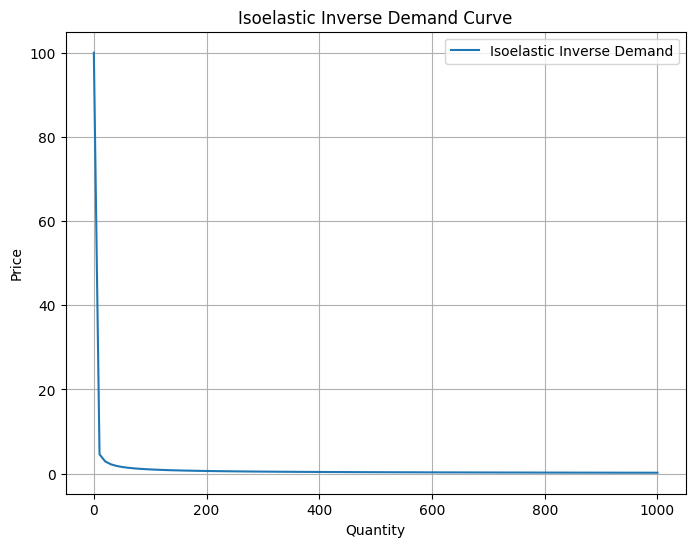

In [11]:
# Plot the demand curve
Q = np.linspace(0.1, 1000, 100)

# Calculating prices using the inverse demand function
P = inv_isoelastic(Q)

# Plotting the inverse demand curve
plt.figure(figsize=(8, 6))
plt.plot(Q, P, label=f'Isoelastic Inverse Demand')
plt.xlabel('Quantity')
plt.ylabel('Price')
plt.title('Isoelastic Inverse Demand Curve')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# Configure optimizer given numerical problems
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    # Cobb-Douglas optimization with explicit bounds away from zero
    for guess in initial_guesses:
        optimal_KL = opt.minimize(neg_profit, guess, args=(inv_isoelastic, cobb_douglas_production), method='L-BFGS-B', bounds=((1e-5, None), (1e-5, None)))
        print(f"Optimal K and L for initial guess {guess}: {optimal_KL.x}, Profit: {-optimal_KL.fun}")

    # Cobb-Douglas optimization with Nelder Mead (derivative free-method)
    for guess in initial_guesses:
            optimal_KL = opt.minimize(neg_profit, guess, args=(inv_isoelastic, cobb_douglas_production), method='Nelder-Mead')
            print(f"Optimal K and L for initial guess {guess}: {optimal_KL.x}, Profit: {-optimal_KL.fun}")

Optimal K and L for initial guess [100, 100]: [0.036796  0.1073216], Profit: 6.132663224140763
Optimal K and L for initial guess [40, 20]: [0.03679597 0.10732163], Profit: 6.132663224140769
Optimal K and L for initial guess [1000, 2000]: [0.03679597 0.1073216 ], Profit: 6.132663224140829
Optimal K and L for initial guess [100, 100]: [0.03678541 0.10730678], Profit: 6.132663182819121
Optimal K and L for initial guess [40, 20]: [0.03681362 0.1073315 ], Profit: 6.132663131523653
Optimal K and L for initial guess [1000, 2000]: [0.03681094 0.10733309], Profit: 6.132663155642231


/var/folders/gd/m9hjf98j03v2xwv7_fz0y_3m0000gn/T/ipykernel_38601/1022323541.py:2: RuntimeWarning: divide by zero encountered in power
  P = (Q / a) ** (-1 / epsilon)
/var/folders/gd/m9hjf98j03v2xwv7_fz0y_3m0000gn/T/ipykernel_38601/1297146946.py:12: RuntimeWarning: invalid value encountered in multiply
  profit = P * Q - w * L - r * K


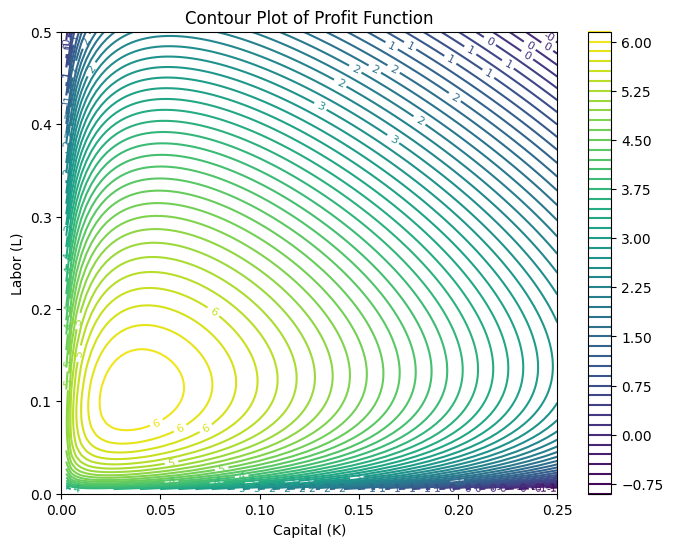

In [13]:
# Plot objective
plot_function(0.25, 0.5, inv_isoelastic, cobb_douglas_production, 'contour')

**Solution:** We are now dealing with an iso-elastic demand curve where demand is elastic since $\epsilon > 1$. Note that the optimum is somewhere close to zero based on the map of the objective function. However, when the optimizer approaches quantities of zero, prices go to infinity and so does the derivative. We might want to configure the optimizer to start at a finite number larger than zero or use a derivative-free method.

7. Now suppose $\epsilon = 0.2$. What does this economically mean for the problem? Solve the optimization problem again and plot the objective function. Why does the optimization not work?

In [14]:
# Define the inelastic case separately so the epsilon = 1.5 version above still works.
def inv_isoelastic_inelastic(Q, a=100, epsilon=0.2):
    return inv_isoelastic(Q, a, epsilon)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    # Cobb-Douglas optimization with explicit bounds away from zero
    for guess in initial_guesses:
        optimal_KL = opt.minimize(neg_profit, guess, args=(inv_isoelastic_inelastic, cobb_douglas_production), method='L-BFGS-B', bounds=((1e-10, None), (1e-10, None)))
        print(f"Optimal K and L for initial guess {guess}: {optimal_KL.x}, Profit: {-optimal_KL.fun}")

    # Cobb-Douglas optimization with Nelder Mead (derivative free-method)
    for guess in initial_guesses:
        optimal_KL = opt.minimize(neg_profit, guess, args=(inv_isoelastic_inelastic, cobb_douglas_production), method='Nelder-Mead')
        print(f"Optimal K and L for initial guess {guess}: {optimal_KL.x}, Profit: {-optimal_KL.fun}")

Optimal K and L for initial guess [100, 100]: [1.e-10 1.e-10], Profit: 9.999999999999953e+49
Optimal K and L for initial guess [40, 20]: [1.e-10 1.e-10], Profit: 9.999999999999953e+49
Optimal K and L for initial guess [1000, 2000]: [1.e-10 1.e-10], Profit: 9.999999999999953e+49
Optimal K and L for initial guess [100, 100]: [5.51362361e-26 1.13165599e+02], Profit: 3.6297362286807008e+34
Optimal K and L for initial guess [40, 20]: [4.66643521e+01 1.29426828e-28], Profit: 1.2121312666657849e+86
Optimal K and L for initial guess [1000, 2000]: [1.13189139e-21 4.87821919e+01], Profit: 2.5603693810059095e+30


/var/folders/gd/m9hjf98j03v2xwv7_fz0y_3m0000gn/T/ipykernel_38601/1022323541.py:2: RuntimeWarning: divide by zero encountered in power
  P = (Q / a) ** (-1 / epsilon)
/var/folders/gd/m9hjf98j03v2xwv7_fz0y_3m0000gn/T/ipykernel_38601/1297146946.py:12: RuntimeWarning: invalid value encountered in multiply
  profit = P * Q - w * L - r * K


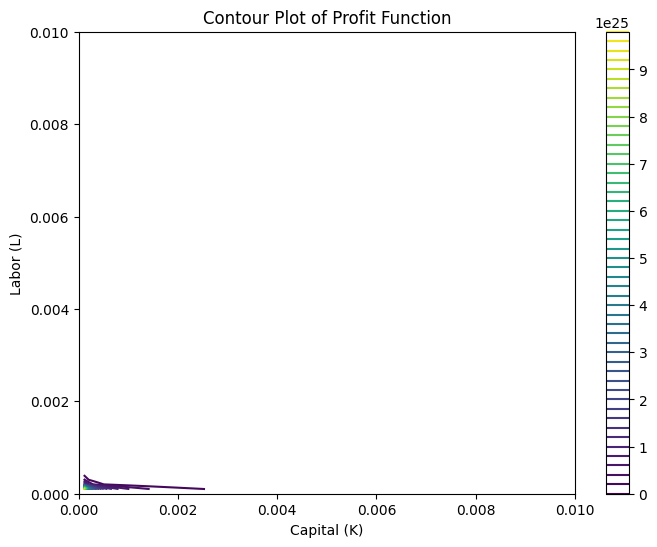

In [15]:
# Plot objective
plot_function(0.01, 0.01, inv_isoelastic_inelastic, cobb_douglas_production, 'contour')

**Solution:** Since $\epsilon = 0.2 < 1$, demand is inelastic and there is no profit-maximizing price when costs are nonnegative since the firm can always increase revenue by increasing prices and decreasing quantity. Whatever a solver returns here, it is not a solution! For example, with any sort of bounds, the solver will return the lowest bound above zero. This is a good reminder to think about the economics and mathematics of a problem before handing it to a solver.

## Exercise: Nonlinear Equation Solving

1. <font color='red'> [Write it yourself]</font> <font color = 'pink'> [Check with AI]</font> Write up a function that will find the root of a given a univariate function $f$ with the option of using the bisection method, Newton's method, quasi-Newton method (secant method in the univariate case), and fixed-point iteration. Remember which methods require initial values or brackets. Set a tolerance and/or maximum number of iterations. Incorporate error outputs in your function. For taking derivatives, feel free to use Python's `scipy.optimize.approx_fprime`.

We have provided the docstring and most of the function, please fill in the parts labeled ```# Your code here```. Try writing this yourself, and then ask AI to check your code and improve it. What changes did AI make, and how does the final code differ from your initial attempt? Do you agree with the new version?



In [16]:
def find_root(f, method, x0=None, bracket=None, tolerance=1e-8, max_iterations=200):
    """
    Find the root of a function f using the specified method and return the root and the number of iterations.

    Parameters:
    - f: The function for which to find the root.
    - method: The method to use ('bisect', 'newton', 'secant', 'fixed-point').
    - x0: The initial guess for 'newton', 'secant', and 'fixed-point' methods.
    - bracket: The bracket [a, b] for the 'bisect' method, where f(a)*f(b) < 0.
    - tolerance: The tolerance for stopping the search.
    - max_iterations: The maximum number of iterations.

    Returns:
    - A tuple containing the approximate root of the function and the number of iterations used.
    """
    # sqrt(machine epsilon) is the usual step for a forward difference; much smaller
    # steps (e.g. 1e-10) lose accuracy to roundoff.
    fd_step = np.sqrt(np.finfo(float).eps)

    iterations = 0  # Initialize iterations counter

    if method not in ['bisect', 'newton', 'secant', 'fixed-point']:
        raise ValueError("Unsupported method. Choose from 'bisect', 'newton', 'secant', 'fixed-point'.")

    if method == 'bisect':
        if bracket is None:
            raise ValueError("Bracket required for bisection method.")
        a, b = bracket
        if f(a) * f(b) >= 0:
            raise ValueError("f(a) and f(b) must have opposite signs for the bisection method.")
        for iterations in range(1, max_iterations + 1):
            midpoint = (a + b) / 2
            if f(midpoint) == 0 or (b - a) / 2 < tolerance:
                return midpoint, iterations
            elif f(a) * f(midpoint) < 0:
                b = midpoint
            else:
                a = midpoint
        return (a + b) / 2, iterations

    elif method in ['newton', 'secant', 'fixed-point']:
        if x0 is None:
            raise ValueError("Initial guess x0 required for Newton's, quasi-Newton's, and fixed-point methods.")

        # Initial guess for solution and derivative
        x = x0
        gradient = opt.approx_fprime(np.array([x]), f, fd_step)[0]

        for iterations in range(1, max_iterations + 1):

            if method == 'newton':
                gradient = opt.approx_fprime(np.array([x]), f, fd_step)[0]
                if gradient == 0:
                    raise ValueError("Derivative underflowed to zero; the iterates may be diverging.")
                x_new = x - f(x) / gradient
            elif method == 'secant':
                x_new = x - f(x) / gradient
                if f(x_new) - f(x) == 0:
                    raise ValueError("Division by zero in secant method. Choose different initial points.")
                gradient = (f(x_new) - f(x)) / (x_new - x)

            else:  # fixed-point
                x_new = f(x)

            if abs(x_new - x) < tolerance:
                return x_new, iterations
            x = x_new

    else:
        raise ValueError("Invalid method.")

    return None, iterations  # Return None if the root was not found within the max iterations

2. <font color = 'orange'> [AI Edit & Human Review]</font> Ask AI to try out your root-solver for the following functions. In your writeup below, address the following:

- Which method(s) did you use and why? If you told AI which methods to use, explain your logic. If you let AI decide which methods to use, do you agree with its decisions? Why or why not?

Also tell AI which initial values you want to use; use at least two different initial values for each method you attempt and comment on how the initial value affects the root-solver efficacy.


*   $f(x) = \log(x-1)$
*   $f(x) = \frac{2}{3}\sin(x) - x + 2$
*   $f(x) = \arctan(x)$




In [17]:
def batch_root_finding(functions, methods, starting_points, brackets):
    """
    Loops through a set of functions, applying specified root-finding methods with given starting values or brackets.

    Parameters:
    - functions: A list of functions to find roots for.
    - methods: A list of strings indicating which methods to use ('newton', 'secant', 'bisect', 'fixed-point').
    - starting_points: A list of starting values for methods that require an initial guess.
    - brackets: A list of two tuples, each a bracket (a, b) for the bisection method.
    """
    for f in functions:
        print(f"Finding roots for function: {f.__name__}")
        for method in methods:
            print(f"  Method: {method}")
            for i, start in enumerate(starting_points if method != 'bisect' else brackets):
                try:
                    if method == 'bisect':
                        root, iterations = find_root(f, method, bracket=start)
                    else:
                        root, iterations = find_root(f, method, x0=start)
                    print(f"    Starting value {i+1}: {start}, Root found: {root}, Iterations: {iterations}")
                except ValueError as e:
                    print(f"    Starting value {i+1}: {start}, Error: {e}")
        print()

In [18]:
# Define the functions
def f1(x):
    return np.log(x - 1)

def f2(x):
    return (2/3)*np.sin(x) - x + 2

def f3(x):
    return np.arctan(x)

# Call upon functions
functions = [f1, f2, f3]

methods = ['bisect', 'newton', 'secant']
starting_points = [1.01, 3, -2]  # Example starting points for methods other than bisection
brackets = [(1.1, 4), (-2, 4)]  # Example brackets for bisection method

# Call the batch root finding function
batch_root_finding(functions, methods, starting_points, brackets)

Finding roots for function: f1
  Method: bisect
    Starting value 1: (1.1, 4), Root found: 2.0000000020489104, Iterations: 29
    Starting value 2: (-2, 4), Root found: 2.000000001862645, Iterations: 30
  Method: newton
    Starting value 1: 1.01, Root found: 2.0, Iterations: 8
    Starting value 2: 3, Root found: 2.0, Iterations: 6
    Starting value 3: -2, Root found: None, Iterations: 200
  Method: secant
    Starting value 1: 1.01, Root found: 2.0, Iterations: 11
    Starting value 2: 3, Root found: 2.0, Iterations: 8
    Starting value 3: -2, Root found: None, Iterations: 200

Finding roots for function: f2
  Method: bisect
    Starting value 1: (1.1, 4), Root found: 2.4335602471604947, Iterations: 29
    Starting value 2: (-2, 4), Root found: 2.433560246601701, Iterations: 30
  Method: newton
    Starting value 1: 1.01, Root found: 2.4335602434120815, Iterations: 5
    Starting value 2: 3, Root found: 2.433560243412082, Iterations: 4
    Starting value 3: -2, Root found: 2.43356

/var/folders/gd/m9hjf98j03v2xwv7_fz0y_3m0000gn/T/ipykernel_38601/735316538.py:3: RuntimeWarning: invalid value encountered in log
  return np.log(x - 1)
/var/folders/gd/m9hjf98j03v2xwv7_fz0y_3m0000gn/T/ipykernel_38601/735316538.py:3: RuntimeWarning: divide by zero encountered in log
  return np.log(x - 1)


In [19]:
# Fixed point method requires a slightly different formulation of the equation
def f2_fixed_point(x):
    return (2/3)*np.sin(x) + 2

batch_root_finding([f2_fixed_point], ['fixed-point'], starting_points, brackets)

Finding roots for function: f2_fixed_point
  Method: fixed-point
    Starting value 1: 1.01, Root found: 2.43356024621544, Iterations: 27
    Starting value 2: 3, Root found: 2.4335602464981028, Iterations: 28
    Starting value 3: -2, Root found: 2.433560240969353, Iterations: 29



**Solution:** Bisection is reliable as long as the two initial values are different signs, but will require more iterations than derivative-based methods which converge quicker. However, the initial value is important for derivative-based methods. $f(x) = \log(x-1)$ has an asymptote at $x=1$, and the Newton step $x_{n+1} = x_n - (x_n-1)\log(x_n-1)$ overshoots past it whenever $x_n > 1 + e \approx 3.72$, so only starting values in $(1, 1+e)$ converge. The $\sin$ function is well-behaved and can work with any root-solver, including fixed-point iteration. $\arctan$ has two horizontal asymptotes, making bisection the most reliable method since initial values that are too far away from zero will lead to divergent behavior in Newtonian methods.

3. We have provided a plotting function. You may use it to plot out each function (or use your own code or AI-generated code if you prefer). For each function, would you change the root solver or the initial values you used? Why or why not?

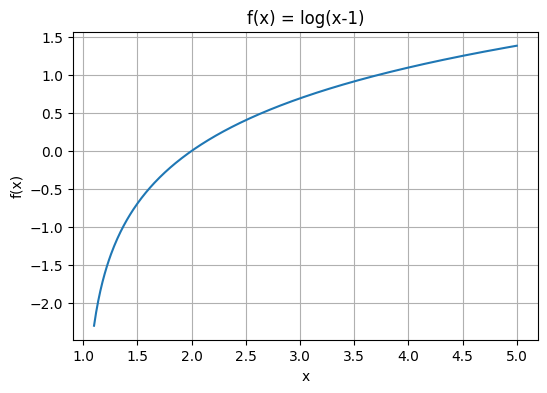

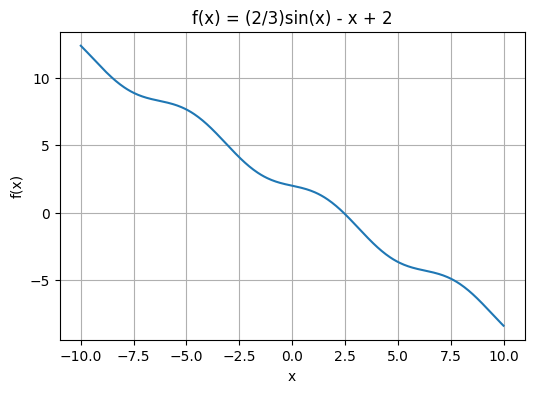

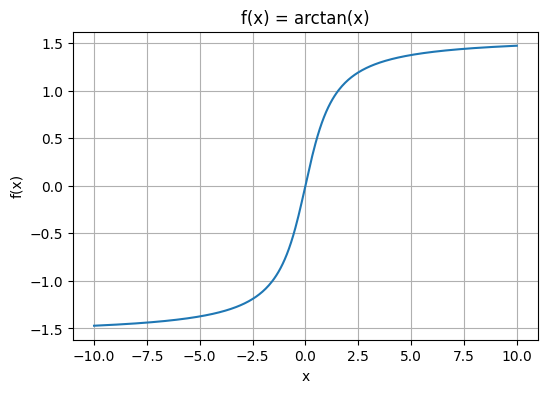

In [20]:
def plot_univariate_function(f, x_range, title, xlabel='x', ylabel='f(x)'):
    """
    Plots a given mathematical function f over a specified range of x values.

    Parameters:
    - f: The mathematical function to plot. It should accept a numpy array and return a numpy array.
    - x_range: A tuple specifying the start and end of the x values range.
    - title: The title of the plot.
    - xlabel: Label for the x-axis.
    - ylabel: Label for the y-axis.
    """
    # Generate x values within the specified range
    x = np.linspace(x_range[0], x_range[1], 400)

    # Calculate y values using the provided function
    y = f(x)

    # Create the plot
    plt.figure(figsize=(6, 4))
    plt.plot(x, y, label=title)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

# Plot each function
plot_univariate_function(f1, (1.1, 5), 'f(x) = log(x-1)')
plot_univariate_function(f2, (-10, 10), 'f(x) = (2/3)sin(x) - x + 2')
plot_univariate_function(f3, (-10, 10), 'f(x) = arctan(x)')

4. Suppose we want to solve the root of the function $f(x) = x^3 - 2x + 2$. For bisection and Newton's method, compare the (1) time and (2) iterations with Python's equivalent root-finders.

* `scipy.optimize.root_scalar(method='bisect')`
* `scipy.optimize.root_scalar(method='newton')`

Report the total time and average number of iterations for 1000 random initial values. How do the results compare depending on the initial values?


In [21]:
def f(x):
    return x**3 - 2*x + 2

def f_prime(x):
    return 3*x**2 - 2

def compare_root_solvers(f, methods, initial_guesses, brackets, fprime=None, tol=1e-8):
    """
    Compares the performance of different root-solving algorithms.

    Parameters:
    - f: The function for which we are trying to find a root.
    - methods: A list of strings indicating the root-solving methods to compare (e.g. bisect, newton)
    - initial_guesses: An array of initial guesses for the root.
    - brackets: Array of tuples as starting brackets for the bisection method.
    - fprime: The derivative of f. Needed for 'newton': root_scalar silently falls back to the
      secant method when no derivative is given, which would not be a like-for-like comparison.
    - tol: The tolerance for convergence (default: 1e-8). Passed to both implementations so that
      the iteration counts are comparable.

    Prints the results of each method, including the average root over the runs that converged,
    the number of failures, the number of iterations, and the time taken for both implementations.
    """
    for method in methods:

        # Initializing
        N = brackets.shape[0] if method == "bisect" else len(initial_guesses)

        total_time = np.zeros(2)
        total_iterations = np.zeros(2)
        roots = ([], [])
        failures = np.zeros(2)

        for i in range(N):

            bracket = brackets[i]

            # Measure time and iterations for your method
            start_time = time.perf_counter()
            try:
                root_your, iterations_your = find_root(f, method, x0=initial_guesses[i], bracket=bracket, tolerance=tol)
            except ValueError:
                root_your, iterations_your = None, 200
            your_time = time.perf_counter() - start_time

            # Measure time and iterations for scipy's method, at the same tolerance
            start_time = time.perf_counter()
            if method == "newton":
                result = opt.root_scalar(f, x0=initial_guesses[i], fprime=fprime, method=method, xtol=tol)
            else:
                result = opt.root_scalar(f, bracket=bracket, method=method, xtol=tol)
            scipy_time = time.perf_counter() - start_time

            # Record results, keeping runs that did not converge out of the average root
            total_time += np.array([your_time, scipy_time])
            total_iterations += np.array([iterations_your, result.iterations])
            for j, (root, converged) in enumerate([(root_your, root_your is not None),
                                                   (result.root, result.converged)]):
                if converged:
                    roots[j].append(root)
                else:
                    failures[j] += 1

        print(f"Method: {method}")
        for j, label in enumerate([f"Your {method} method", f"Scipy's {method} method"]):
            avg_root = np.mean(roots[j]) if roots[j] else np.nan
            print(f"  {label}: average root = {avg_root}, failures = {int(failures[j])}/{N}, "
                  f"average iterations = {total_iterations[j] / N}, total time = {total_time[j]} for {N} runs")

In [22]:
# Compare root solvers
np.random.seed(0)
methods = ['bisect', 'newton']
initial_guesses = np.random.uniform(-10, 10, 1000)
brackets = np.column_stack((np.random.uniform(-20, -3, 1000), np.random.uniform(0, 20, 1000)))
compare_root_solvers(f, methods, initial_guesses, brackets, fprime=f_prime)

Method: bisect
  Your bisect method: average root = -1.76929235412998, failures = 0/1000, average iterations = 31.376, total time = 0.014299760659923777 for 1000 runs
  Scipy's bisect method: average root = -1.76929235412998, failures = 0/1000, average iterations = 31.376, total time = 0.015048305242089555 for 1000 runs


Method: newton


  Your newton method: average root = -1.7692923542386312, failures = 158/1000, average iterations = 43.968, total time = 1.18555546796415 for 1000 runs
  Scipy's newton method: average root = -1.7692923542386314, failures = 181/1000, average iterations = 19.784, total time = 0.1310009194421582 for 1000 runs


In [23]:
np.random.seed(1)
initial_guesses = np.random.uniform(-20, -1, 1000)
compare_root_solvers(f, ['newton'], initial_guesses, brackets, fprime=f_prime)

Method: newton
  Your newton method: average root = -1.7692923542386312, failures = 0/1000, average iterations = 9.159, total time = 0.19889272129512392 for 1000 runs
  Scipy's newton method: average root = -1.7692923542386312, failures = 0/1000, average iterations = 9.147, total time = 0.06172717537265271 for 1000 runs


**Solution:** Bisection is reliable and hardly depends on the starting bracket: at the same tolerance both implementations take the same ~31 iterations and never fail. Newton's method is much more sensitive to the initial value. Drawing starting values anywhere in $[-10, 10]$ straddles the inflection points and about 16% of runs fail to converge within 200 iterations. Restricting them to the well-behaved part of the function ($[-20, -1]$) drops that to zero and cuts the average to about 9 iterations. Note that fewer iterations does not mean less time: each of our Newton steps spends two extra function evaluations on the finite-difference derivative, so it stays slower than bisection here, and slower than SciPy's Newton, which is handed the analytic derivative.

# Submission ⭐

Congratulations you finished this module! We will handle all exercise submissions on GitHub classroom. In order to access this assignment, you should already have a GitHub account with an associated repository unique to you. Please submit the assignment in that repository.